In [126]:
import numpy as np
import openml
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
CLASS_LABELS = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

dataset = openml.datasets.get_dataset(1478)
X, y, *_ = dataset.get_data(target=dataset.default_target_attribute)
X.shape, y.shape

((10299, 561), (10299,))

In [3]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989303,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [4]:
np.unique(y, return_counts=True)

(array(['1', '2', '3', '4', '5', '6'], dtype=object),
 array([1722, 1544, 1406, 1777, 1906, 1944]))

In [5]:
pd.DataFrame({"mean": X.mean(), "std": X.std()})

,mean,std
V1,0.274347,0.067628
V2,-0.017743,0.037128
V3,-0.108925,0.053033
V4,-0.607784,0.438694
V5,-0.510191,0.500240
...,...,...
V557,0.017683,0.616189
V558,-0.009219,0.484770
V559,-0.496522,0.511158
V560,0.063255,0.305468


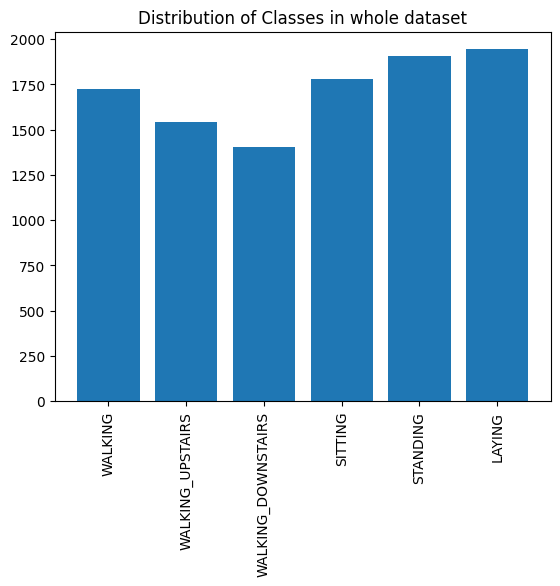

In [14]:
_, counts = np.unique(y, return_counts=True)
plt.bar(CLASS_LABELS, counts, align='center')
plt.xticks(rotation=90)
plt.title("Distribution of Classes in whole dataset")
plt.show()

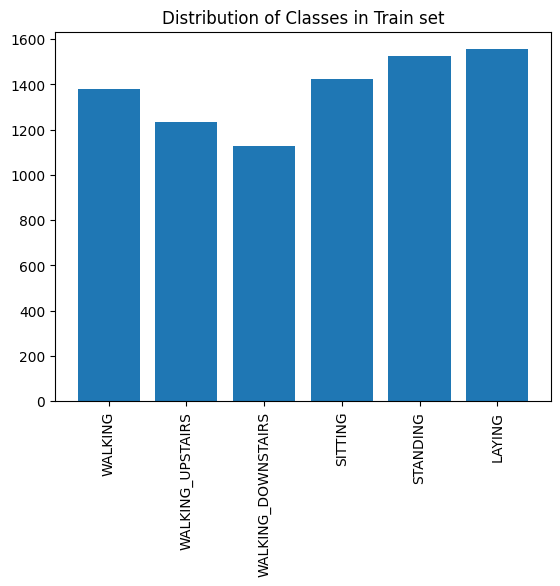

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pd.DataFrame({"mean": X.mean(), "std": X.std()})
_, counts = np.unique(y_train, return_counts=True)
plt.bar(CLASS_LABELS, counts, align='center')
plt.xticks(rotation=90)
plt.title("Distribution of Classes in Train set")
plt.show()

In [181]:
rnd = np.random.RandomState(42)
random_columns = rnd.choice(X_train.columns, 12, replace=False)
random_columns

array(['V514', 'V343', 'V178', 'V87', 'V334', 'V141', 'V322', 'V532',
       'V102', 'V520', 'V412', 'V555'], dtype=object)

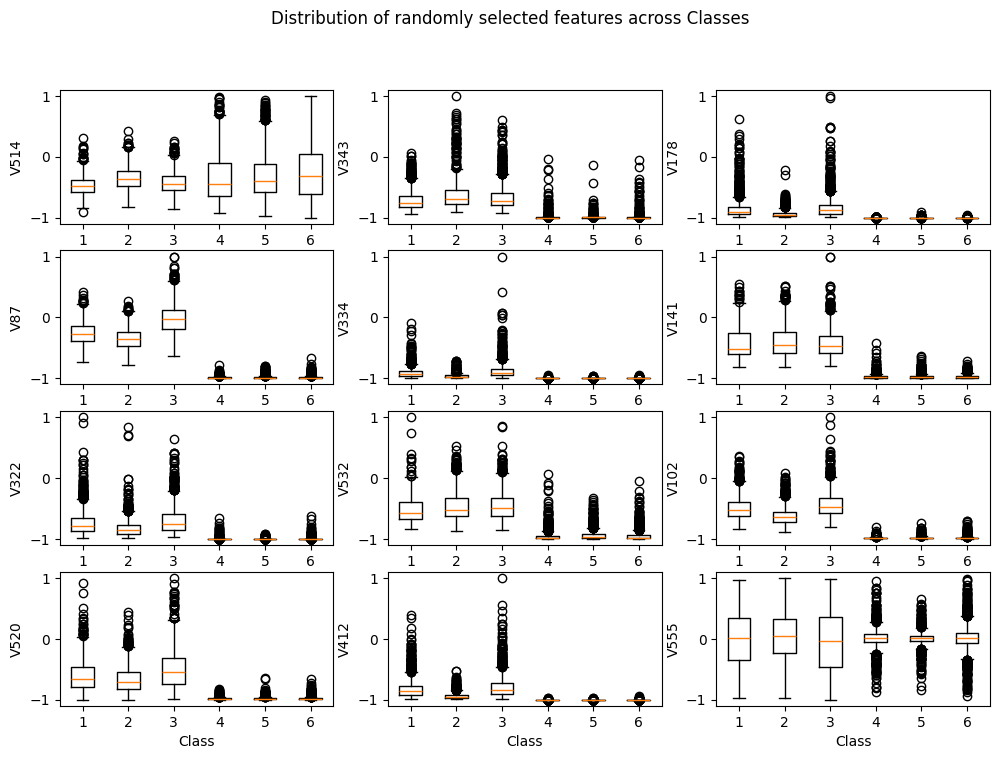

In [180]:
from math import ceil

n_rows = ceil(len(random_columns)/3)
fig, axs = plt.subplots(n_rows, 3, figsize=(12, 2*n_rows))
axs = axs.flatten()

for col_idx, column in enumerate(random_columns):
    ax = axs[col_idx]
    x_at_col = X_train[column]
    to_plot = [x_at_col[y == str(i+1)] for i in range(len(CLASS_LABELS))]
    ax.boxplot(to_plot)
    ax.set_ylabel(column)
    ax.set_xlabel("Class")

fig.suptitle("Distribution of randomly selected features across Classes")
plt.show()